# MobileNetV3 Training Notebook (PSM)

This notebook mirrors the MobileNetV2 workflow and adapts it for MobileNetV3Small.

## Goals
- Train a MobileNetV3 CNN model for palm fruit ripeness classification.
- Keep directory conventions and output artifacts compatible with the current project pipeline.
- Produce `.h5` artifacts for TFLite conversion and edge deployment.

## Expected Input Directory
- `DATASET_ROOT/Train/<class_name>/*.jpg|*.png`
- `DATASET_ROOT/Test/<class_name>/*.jpg|*.png`

Default class folders are expected in alphabetical order, for example:
- `Overripe`
- `Ripe`
- `Underripe`

## Expected Output Directory
- Model checkpoints: `saved_models/`
- Reports and metrics: `reports/`
- Experiment log: `reports/experiment_log.csv`

In [2]:
import os
import json
import random
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as preprocess_input_mobilenet_v3

# ---------------- Configuration ----------------
DATASET_ROOT = Path(os.getenv("DATASET_ROOT", r"C:\Users\jeffy\Documents\PSM\Dataset1"))
TRAIN_ROOT = Path(os.getenv("TRAIN_ROOT", str(DATASET_ROOT / "Train")))
TEST_ROOT = Path(os.getenv("TEST_ROOT", str(DATASET_ROOT / "Test")))

SAVED_MODELS_DIR = Path(os.getenv("MODEL_DIR", "saved_models"))
REPORTS_DIR = Path(os.getenv("REPORTS_DIR", "reports"))
EXPERIMENT_LOG_PATH = REPORTS_DIR / "experiment_log.csv"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
SEED = 42

USE_IMAGENET = True
DO_SMOKE = False
DO_FINE_TUNE = True
EPOCHS = 30
FINE_TUNE_EPOCHS = 15
INITIAL_LR = 1e-4
FINE_TUNE_LR = 1e-5
FINE_TUNE_UNFREEZE_LAYERS = 30

MODEL_NAME = "MobileNetV3Small"
PREPROCESS_FAMILY = "mobilenet_v3"
INCLUDE_PREPROCESSING_LAYER = True  # Keep True to follow Keras MobileNetV3 default path.

TIMESTAMP = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
BEST_MODEL_PATH = SAVED_MODELS_DIR / f"palm_ripeness_best_{TIMESTAMP}.h5"
FINAL_MODEL_PATH = SAVED_MODELS_DIR / f"palm_ripeness_final_{TIMESTAMP}.h5"
FINETUNED_MODEL_PATH = SAVED_MODELS_DIR / f"palm_ripeness_finetuned_{TIMESTAMP}.h5"

CONFUSION_MATRIX_PATH = REPORTS_DIR / f"confusion_matrix_{TIMESTAMP}.png"
CLASSIFICATION_METRICS_PATH = REPORTS_DIR / f"classification_metrics_{TIMESTAMP}.png"
CLASSIFICATION_REPORT_XLSX = REPORTS_DIR / f"classification_report_{TIMESTAMP}.xlsx"

for directory in [SAVED_MODELS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

autotune = tf.data.AUTOTUNE

print("TensorFlow:", tf.__version__)
print("Model:", MODEL_NAME)
print("Preprocess family:", PREPROCESS_FAMILY)
print("Dataset root:", DATASET_ROOT)
print("Train root:", TRAIN_ROOT)
print("Test root:", TEST_ROOT)
print("Output model dir:", SAVED_MODELS_DIR)
print("Output reports dir:", REPORTS_DIR)
print("Best model path:", BEST_MODEL_PATH)

TensorFlow: 2.21.0
Model: MobileNetV3Small
Preprocess family: mobilenet_v3
Dataset root: C:\Users\jeffy\Documents\PSM\Dataset1
Train root: C:\Users\jeffy\Documents\PSM\Dataset1\Train
Test root: C:\Users\jeffy\Documents\PSM\Dataset1\Test
Output model dir: saved_models
Output reports dir: reports
Best model path: saved_models\palm_ripeness_best_20260420_174107.h5


In [4]:
# ---------------- Data contract checks ----------------
from pathlib import Path

if "TRAIN_ROOT" not in globals() or "TEST_ROOT" not in globals():
    raise RuntimeError(
        "TRAIN_ROOT/TEST_ROOT are not defined. "
        "Run Cell 2 (Imports & Configuration) first."
    )


def list_class_names(root: Path):
    return sorted([p.name for p in root.iterdir() if p.is_dir()])


def count_images(root: Path):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sum(1 for p in root.rglob("*") if p.is_file() and p.suffix.lower() in exts)

if not TRAIN_ROOT.exists():
    raise FileNotFoundError(f"Train directory not found: {TRAIN_ROOT}")
if not TEST_ROOT.exists():
    raise FileNotFoundError(f"Test directory not found: {TEST_ROOT}")

CLASS_NAMES = list_class_names(TRAIN_ROOT)
TEST_CLASS_NAMES = list_class_names(TEST_ROOT)

if not CLASS_NAMES:
    raise ValueError(f"No class folders found under train root: {TRAIN_ROOT}")
if CLASS_NAMES != TEST_CLASS_NAMES:
    raise ValueError(
        "Train/Test class folders do not match. "
        f"Train={CLASS_NAMES}, Test={TEST_CLASS_NAMES}"
    )

NUM_CLASSES = len(CLASS_NAMES)
TRAIN_IMAGE_COUNT = count_images(TRAIN_ROOT)
TEST_IMAGE_COUNT = count_images(TEST_ROOT)

print("Classes:", CLASS_NAMES)
print("Num classes:", NUM_CLASSES)
print("Train images:", TRAIN_IMAGE_COUNT)
print("Test images:", TEST_IMAGE_COUNT)

Classes: ['Overripe', 'Ripe', 'Underripe']
Num classes: 3
Train images: 1200
Test images: 180


In [5]:
# ---------------- Dataset loading ----------------
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_ROOT,
    labels="inferred",
    label_mode="categorical",
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_ROOT,
    labels="inferred",
    label_mode="categorical",
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_ROOT,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

if train_ds_raw.class_names != CLASS_NAMES:
    raise ValueError(
        f"Class order mismatch. expected={CLASS_NAMES}, got={train_ds_raw.class_names}"
    )

if DO_SMOKE:
    train_ds_raw = train_ds_raw.take(2)
    val_ds_raw = val_ds_raw.take(1)
    test_ds_raw = test_ds_raw.take(1)

print("Train batches:", tf.data.experimental.cardinality(train_ds_raw).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds_raw).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds_raw).numpy())

Found 1200 files belonging to 3 classes.
Using 960 files for training.
Found 1200 files belonging to 3 classes.
Using 240 files for validation.
Found 180 files belonging to 3 classes.
Train batches: 30
Val batches: 8
Test batches: 6


In [6]:
# ---------------- Preprocessing and augmentation ----------------
def apply_preprocess(x: tf.Tensor) -> tf.Tensor:
    x = tf.cast(x, tf.float32)
    if PREPROCESS_FAMILY == "mobilenet_v3":
        return preprocess_input_mobilenet_v3(x)
    if PREPROCESS_FAMILY == "none":
        return x
    raise ValueError(f"Unsupported PREPROCESS_FAMILY={PREPROCESS_FAMILY}")


def preprocess_xy(x, y):
    return apply_preprocess(x), y


train_ds = (
    train_ds_raw
    .map(preprocess_xy, num_parallel_calls=autotune)
    .apply(tf.data.experimental.ignore_errors())
    .prefetch(autotune)
)
val_ds = (
    val_ds_raw
    .map(preprocess_xy, num_parallel_calls=autotune)
    .apply(tf.data.experimental.ignore_errors())
    .prefetch(autotune)
)
test_ds = (
    test_ds_raw
    .map(preprocess_xy, num_parallel_calls=autotune)
    .apply(tf.data.experimental.ignore_errors())
    .prefetch(autotune)
)

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.15),
        tf.keras.layers.RandomZoom(0.10),
    ],
    name="data_augmentation",
)

print("Preprocessing family:", PREPROCESS_FAMILY)
print("MobileNetV3 include_preprocessing layer:", INCLUDE_PREPROCESSING_LAYER)

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.
Preprocessing family: mobilenet_v3
MobileNetV3 include_preprocessing layer: True


In [7]:
# ---------------- Build model ----------------
input_tensor = tf.keras.Input(shape=(*IMG_SIZE, 3), name="image")
x = data_augmentation(input_tensor)

if MODEL_NAME == "MobileNetV3Small":
    base_model = tf.keras.applications.MobileNetV3Small(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights="imagenet" if USE_IMAGENET else None,
        include_preprocessing=INCLUDE_PREPROCESSING_LAYER,
    )
elif MODEL_NAME == "MobileNetV3Large":
    base_model = tf.keras.applications.MobileNetV3Large(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights="imagenet" if USE_IMAGENET else None,
        include_preprocessing=INCLUDE_PREPROCESSING_LAYER,
    )
else:
    raise ValueError(f"Unsupported MODEL_NAME={MODEL_NAME}")

base_model.trainable = False
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.20)(x)
output_tensor = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="ripeness_probs")(x)

model = tf.keras.Model(input_tensor, output_tensor, name="PalmRipeness_MobileNetV3")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "PalmRipeness_MobileNetV3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ripeness_probs (Dense)          │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013,875 (3.87 MB)

 Trainable params: 74,499 (291.01 KB)

 Non-trainable params: 939,376 (3.58 MB)

In [8]:
# ---------------- Callbacks ----------------
monitor_metric = "val_loss"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor=monitor_metric,
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor=monitor_metric,
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor=monitor_metric,
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
]

print("Callbacks ready. Best checkpoint will be saved to:", BEST_MODEL_PATH)

Callbacks ready. Best checkpoint will be saved to: saved_models\palm_ripeness_best_20260420_174107.h5


In [ ]:
# ---------------- Phase 1: warm-up training ----------------
warmup_epochs = 1 if DO_SMOKE else EPOCHS

history_initial = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=warmup_epochs,
    callbacks=callbacks,
    verbose=1,
)

model.save(str(FINAL_MODEL_PATH))
print("Saved phase-1 model to:", FINAL_MODEL_PATH)

Epoch 1/30
     30/Unknown 7s 86ms/step - accuracy: 0.3612 - loss: 1.5549

c:\Users\jeffy\Documents\PSM\Project Coding\PSM_PalmFruitRipenessClassificationSystem\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 1.21514, saving model to saved_models\palm_ripeness_best_20260420_174107.h5



Epoch 1: finished saving model to saved_models\palm_ripeness_best_20260420_174107.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.3802 - loss: 1.4839 - val_accuracy: 0.4917 - val_loss: 1.2151 - learning_rate: 1.0000e-04
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.4585 - loss: 1.2879
Epoch 2: val_loss improved from 1.21514 to 0.95136, saving model to saved_models\palm_ripeness_best_20260420_174107.h5



Epoch 2: finished saving model to saved_models\palm_ripeness_best_20260420_174107.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.4719 - loss: 1.2455 - val_accuracy: 0.5333 - val_loss: 0.9514 - learning_rate: 1.0000e-04
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5410 - loss: 1.0763
Epoch 3: val_loss improved from 0.95136 to 0.77077, saving model to saved_models\palm_ripeness_best_20260420_174107.h5



Epoch 3: finished saving model to saved_models\palm_ripeness_best_20260420_174107.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.5427 - loss: 1.0768 - val_accuracy: 0.6458 - val_loss: 0.7708 - learning_rate: 1.0000e-04
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5855 - loss: 0.9544
Epoch 4: val_loss improved from 0.77077 to 0.66188, saving model to saved_models\palm_ripeness_best_20260420_174107.h5



Epoch 4: finished saving model to saved_models\palm_ripeness_best_20260420_174107.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 0.6083 - loss: 0.8990 - val_accuracy: 0.7000 - val_loss: 0.6619 - learning_rate: 1.0000e-04
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.6065 - loss: 0.9147
Epoch 5: val_loss improved from 0.66188 to 0.59775, saving model to saved_models\palm_ripeness_best_20260420_174107.h5



Epoch 5: finished saving model to saved_models\palm_ripeness_best_20260420_174107.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 0.6271 - loss: 0.8973 - val_accuracy: 0.7625 - val_loss: 0.5978 - learning_rate: 1.0000e-04
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6323 - loss: 0.8918
Epoch 6: val_loss improved from 0.59775 to 0.54567, saving model to saved_models\palm_ripeness_best_20260420_174107.h5


In [ ]:
# ---------------- Phase 2: fine-tuning ----------------
history_fine = None

if DO_FINE_TUNE and not DO_SMOKE:
    print("\n--- Fine-tuning: unfreezing top layers of MobileNetV3 ---")
    base_model.trainable = True

    if FINE_TUNE_UNFREEZE_LAYERS <= 0:
        for layer in base_model.layers:
            layer.trainable = False
    else:
        freeze_until = max(0, len(base_model.layers) - FINE_TUNE_UNFREEZE_LAYERS)
        for layer in base_model.layers[:freeze_until]:
            layer.trainable = False
        for layer in base_model.layers[freeze_until:]:
            layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    history_fine = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    model.save(str(FINETUNED_MODEL_PATH))
    print("Saved fine-tuned model to:", FINETUNED_MODEL_PATH)
else:
    print("Fine-tuning skipped.")


--- Fine-tuning: unfreezing top layers of MobileNetV3 ---
Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.7628 - loss: 0.5968
Epoch 1: val_loss did not improve from 0.42931
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step - accuracy: 0.7651 - loss: 0.5879 - val_accuracy: 0.8589 - val_loss: 0.4380 - learning_rate: 1.0000e-05
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7586 - loss: 0.6097
Epoch 2: val_loss did not improve from 0.42931
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.7601 - loss: 0.5851 - val_accuracy: 0.8589 - val_loss: 0.4467 - learning_rate: 1.0000e-05
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.7761 - loss: 0.5886
Epoch 3: val_loss did not improve from 0.42931
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 175ms/step - accuracy: 0.7923 - loss: 0.5398 - val_accuracy: 0.8427 - val_loss: 0.4516 - learning_rate: 1.0000e-05
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7827 - loss: 0.5778
Epoch 4: val_loss did

Saved fine-tuned model to: saved_models\palm_ripeness_finetuned_20260418_214309.h5


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9000 - loss: 0.3018
Test loss: 0.3018
Test accuracy: 0.9000


c:\Users\jeffy\Documents\PSM\Project Coding\PSM_PalmFruitRipenessClassificationSystem\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


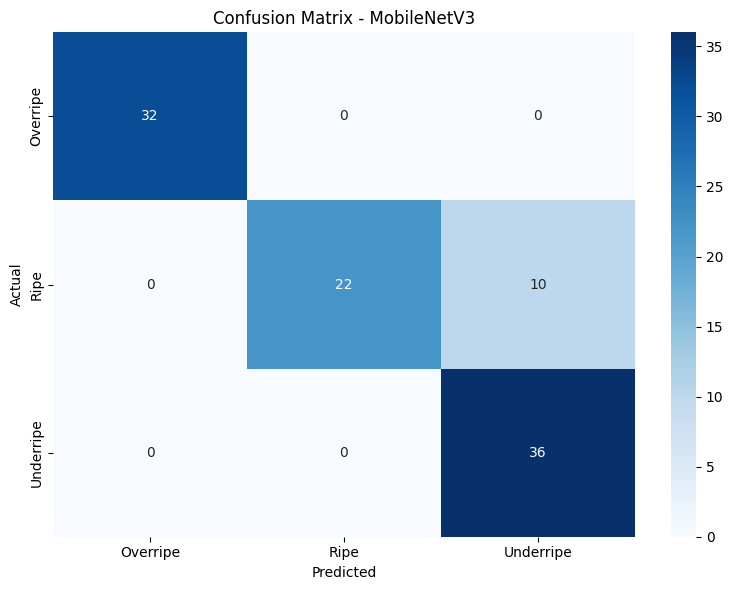

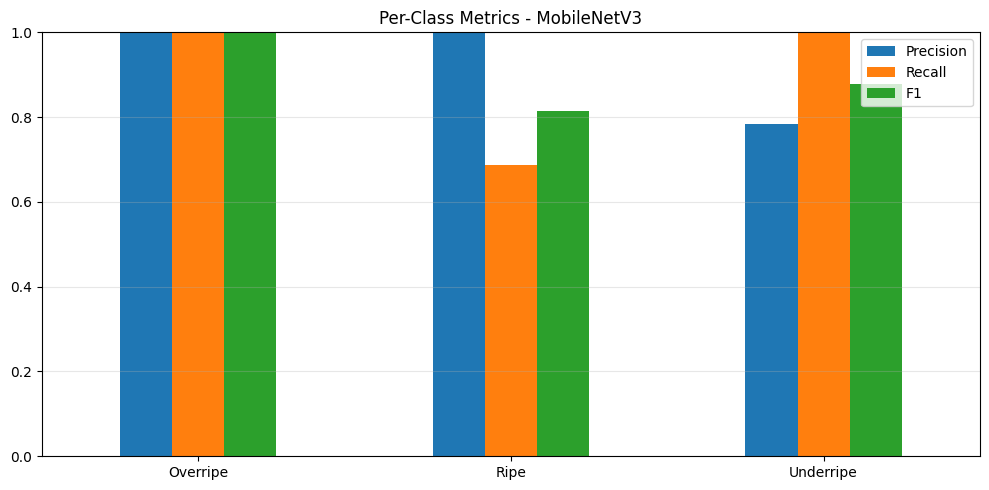

Macro precision: 0.9275
Macro recall: 0.8958
Macro F1: 0.8976
Saved confusion matrix: reports\confusion_matrix_20260418_214309.png
Saved metrics plot: reports\classification_metrics_20260418_214309.png
Saved report workbook: reports\classification_report_20260418_214309.xlsx


In [ ]:
# ---------------- Evaluation and report artifacts ----------------
# Use the in-memory model state after training/fine-tuning.
best_model = model

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

y_true = []
y_pred = []
for x_batch, y_batch in test_ds:
    probs = best_model.predict(x_batch, verbose=0)
    y_true.extend(np.argmax(y_batch.numpy(), axis=1).tolist())
    y_pred.extend(np.argmax(probs, axis=1).tolist())

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="macro",
    zero_division=0,
)

report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    output_dict=True,
    zero_division=0,
)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix - MobileNetV3")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=200)
plt.show()

metric_rows = [label for label in CLASS_NAMES if label in report]
metric_df = pd.DataFrame(
    {
        "Precision": [report[label]["precision"] for label in metric_rows],
        "Recall": [report[label]["recall"] for label in metric_rows],
        "F1": [report[label]["f1-score"] for label in metric_rows],
    },
    index=metric_rows,
)

ax = metric_df.plot(kind="bar", figsize=(10, 5))
ax.set_title("Per-Class Metrics - MobileNetV3")
ax.set_ylim(0.0, 1.0)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(CLASSIFICATION_METRICS_PATH, dpi=200)
plt.show()

report_df = pd.DataFrame(report).transpose()
confusion_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)

with pd.ExcelWriter(CLASSIFICATION_REPORT_XLSX) as writer:
    report_df.to_excel(writer, sheet_name="classification_report")
    confusion_df.to_excel(writer, sheet_name="confusion_matrix")

print("Macro precision:", round(float(macro_precision), 4))
print("Macro recall:", round(float(macro_recall), 4))
print("Macro F1:", round(float(macro_f1), 4))
print("Saved confusion matrix:", CONFUSION_MATRIX_PATH)
print("Saved metrics plot:", CLASSIFICATION_METRICS_PATH)
print("Saved report workbook:", CLASSIFICATION_REPORT_XLSX)

In [ ]:
# ---------------- Experiment logging ----------------
run_mode = "smoke_test" if DO_SMOKE else "full_train"
if DO_FINE_TUNE and not DO_SMOKE:
    run_mode = "full_train + fine_tune"

log_row = {
    "timestamp": TIMESTAMP,
    "run_mode": run_mode,
    "epochs_config": EPOCHS,
    "fine_tune_epochs": FINE_TUNE_EPOCHS if (DO_FINE_TUNE and not DO_SMOKE) else 0,
    "batch_size": BATCH_SIZE,
    "val_split": VAL_SPLIT,
    "initial_learning_rate": INITIAL_LR,
    "final_learning_rate": FINE_TUNE_LR if (DO_FINE_TUNE and not DO_SMOKE) else INITIAL_LR,
    "backbone_unfrozen": bool(DO_FINE_TUNE and not DO_SMOKE),
    "train_images": TRAIN_IMAGE_COUNT,
    "test_images": TEST_IMAGE_COUNT,
    "num_classes": NUM_CLASSES,
    "accuracy": round(float(test_acc), 4),
    "macro_precision": round(float(macro_precision), 4),
    "macro_recall": round(float(macro_recall), 4),
    "macro_f1": round(float(macro_f1), 4),
    "best_model_file": str(BEST_MODEL_PATH),
    "excel_report": str(CLASSIFICATION_REPORT_XLSX),
    "notes": (
        f"model={MODEL_NAME}; preprocess_family={PREPROCESS_FAMILY}; "
        f"include_preprocessing_layer={INCLUDE_PREPROCESSING_LAYER}"
    ),
}

log_df = pd.DataFrame([log_row])
if EXPERIMENT_LOG_PATH.exists():
    existing_df = pd.read_csv(EXPERIMENT_LOG_PATH)
    combined_df = pd.concat([existing_df, log_df], ignore_index=True)
else:
    combined_df = log_df

combined_df.to_csv(EXPERIMENT_LOG_PATH, index=False)

print("Experiment log updated:", EXPERIMENT_LOG_PATH)
combined_df.tail(5)

Experiment log updated: reports\experiment_log.csv


,timestamp,run_mode,epochs_config,fine_tune_epochs,batch_size,val_split,initial_learning_rate,final_learning_rate,backbone_unfrozen,train_images,test_images,num_classes,accuracy,macro_precision,macro_recall,macro_f1,best_model_file,excel_report,notes
0,20260418_214309,full_train + fine_tune,30,15,32,0.2,0.0001,0.00001,True,1240,260,3,0.9,0.9275,0.8958,0.8976,saved_models\palm_ripeness_best_20260418_21430...,reports\classification_report_20260418_214309....,model=MobileNetV3Small; preprocess_family=mobi...


In [ ]:
# ---------------- Direct TFLite conversion (notebook fallback) ----------------
# Fallback conversion path to avoid Keras H5 deserialization issues in script-based conversion.
PROJECT_ROOT = Path.cwd().parent
OUTPUT_MODELS_DIR = PROJECT_ROOT / "models"
OUTPUT_MODELS_DIR.mkdir(parents=True, exist_ok=True)

CONVERT_TS = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
BASE_NAME = OUTPUT_MODELS_DIR / f"palm_ripeness_best_{CONVERT_TS}"
LABELS_PATH = OUTPUT_MODELS_DIR / f"labels_{CONVERT_TS}.json"
MANIFEST_PATH = OUTPUT_MODELS_DIR / f"tflite_manifest_{CONVERT_TS}.json"

with open(LABELS_PATH, "w", encoding="utf-8") as f:
    json.dump(CLASS_NAMES, f, ensure_ascii=False, indent=2)


def rep_dataset_gen(data_dir: Path, img_size=(224, 224), take=500):
    files = tf.data.Dataset.list_files(str(data_dir / "*" / "*.*"), shuffle=False)

    def _load(path):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, img_size)
        img = apply_preprocess(img)
        return tf.expand_dims(img, 0)

    for batch in files.map(_load).take(take):
        yield [batch]


# FP32
converter_fp32 = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_fp32 = converter_fp32.convert()
FP32_PATH = f"{BASE_NAME}_fp32.tflite"
with open(FP32_PATH, "wb") as f:
    f.write(tflite_fp32)

# FP16
converter_fp16 = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter_fp16.optimizations = [tf.lite.Optimize.DEFAULT]
converter_fp16.target_spec.supported_types = [tf.float16]
tflite_fp16 = converter_fp16.convert()
FP16_PATH = f"{BASE_NAME}_float16.tflite"
with open(FP16_PATH, "wb") as f:
    f.write(tflite_fp16)

# INT8 (float input/output for compatibility, same as script)
converter_int8 = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = lambda: rep_dataset_gen(TRAIN_ROOT, IMG_SIZE)
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type = tf.float32
converter_int8.inference_output_type = tf.float32
converter_int8.experimental_new_quantizer = True
tflite_int8 = converter_int8.convert()
INT8_PATH = f"{BASE_NAME}_int8.tflite"
with open(INT8_PATH, "wb") as f:
    f.write(tflite_int8)

manifest = {
    "timestamp": CONVERT_TS,
    "source": "notebook_fallback_conversion",
    "source_h5": str((Path.cwd() / BEST_MODEL_PATH).resolve()),
    "labels": str(LABELS_PATH.resolve()),
    "img_size": IMG_SIZE[0],
    "preprocess_family": PREPROCESS_FAMILY,
    "class_names": CLASS_NAMES,
    "artifacts": {
        "fp32": str(Path(FP32_PATH).resolve()),
        "float16": str(Path(FP16_PATH).resolve()),
        "int8": str(Path(INT8_PATH).resolve()),
    },
}
with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print("Saved labels:", LABELS_PATH)
print("Saved manifest:", MANIFEST_PATH)
print("Saved FP32:", FP32_PATH)
print("Saved FP16:", FP16_PATH)
print("Saved INT8:", INT8_PATH)

INFO:tensorflow:Assets written to: C:\Users\jeffy\AppData\Local\Temp\tmpta1zeae8\assets


INFO:tensorflow:Assets written to: C:\Users\jeffy\AppData\Local\Temp\tmpta1zeae8\assets


Saved artifact at 'C:\Users\jeffy\AppData\Local\Temp\tmpta1zeae8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1275537732048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537729360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537731856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537730704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537726096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537727440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537733968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537731472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537733584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537735312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127553773473

INFO:tensorflow:Assets written to: C:\Users\jeffy\AppData\Local\Temp\tmp_7gyrviq\assets


Saved artifact at 'C:\Users\jeffy\AppData\Local\Temp\tmp_7gyrviq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1275537732048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537729360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537731856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537730704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537726096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537727440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537733968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537731472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537733584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537735312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127553773473

INFO:tensorflow:Assets written to: C:\Users\jeffy\AppData\Local\Temp\tmpcnux79r_\assets


Saved artifact at 'C:\Users\jeffy\AppData\Local\Temp\tmpcnux79r_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1275537732048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537729360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537731856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537730704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537726096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537727440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537733968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537731472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537733584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1275537735312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127553773473

c:\Users\jeffy\Documents\PSM\Project Coding\PSM_PalmFruitRipenessClassificationSystem\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved labels: c:\Users\jeffy\Documents\PSM\Project Coding\PSM_PalmFruitRipenessClassificationSystem\models\labels_20260418_215129.json
Saved manifest: c:\Users\jeffy\Documents\PSM\Project Coding\PSM_PalmFruitRipenessClassificationSystem\models\tflite_manifest_20260418_215129.json
Saved FP32: c:\Users\jeffy\Documents\PSM\Project Coding\PSM_PalmFruitRipenessClassificationSystem\models\palm_ripeness_best_20260418_215129_fp32.tflite
Saved FP16: c:\Users\jeffy\Documents\PSM\Project Coding\PSM_PalmFruitRipenessClassificationSystem\models\palm_ripeness_best_20260418_215129_float16.tflite
Saved INT8: c:\Users\jeffy\Documents\PSM\Project Coding\PSM_PalmFruitRipenessClassificationSystem\models\palm_ripeness_best_20260418_215129_int8.tflite


## Next Step Commands (Conversion, Validation, Runtime)

Use the produced best checkpoint with MobileNetV3 preprocessing compatibility:

```bash
python scripts/convert_tflite.py \
  --h5 saved_models/palm_ripeness_best_<timestamp>.h5 \
  --rep-data <path_to_train_root> \
  --output-dir models \
  --preprocess-family mobilenet_v3
```

```bash
python scripts/validate_tflite.py \
  --model-fp32 models/palm_ripeness_best_<ts>_fp32.tflite \
  --model-int8 models/palm_ripeness_best_<ts>_int8.tflite \
  --labels models/labels_<ts>.json \
  --data-dir <path_to_test_root> \
  --preprocess-family mobilenet_v3
```

Runtime (API/CLI):

```bash
MODEL_PREPROCESS_FAMILY=mobilenet_v3 \
MODEL_PATH=models/palm_ripeness_best_<ts>_int8.tflite \
LABELS_PATH=models/labels_<ts>.json \
python api/app.py
```

```bash
python scripts/pi_inference.py \
  --model models/palm_ripeness_best_<ts>_int8.tflite \
  --labels models/labels_<ts>.json \
  --image <sample_image>.jpg \
  --preprocess-family mobilenet_v3
```

If your MobileNetV3 model is trained with `include_preprocessing=False`, switch preprocessing family to `mobilenet_v2` (or set manual [-1, 1] path) for consistent runtime behavior.